# Liver Disease - Exploratory Data Analysis

## ILPD - Indian Liver Patient Dataset (n=583 raw, 570 after de-duplication)

Liver-function-test panel data. 13 exact duplicate rows are removed during
cleaning (a known characteristic of this dataset, also reported in prior
published work using ILPD) before this notebook's statistics are computed.


In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.config import get_disease
from src.preprocessing import DiseasePreprocessor
from src import eda

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)


In [2]:
disease = get_disease("liver")
pre = DiseasePreprocessor(disease)
raw_df = pre.load_raw()
df = pre.clean_raw(raw_df)
print(f"Shape after cleaning: {df.shape}")
df.head()

2026-07-30 15:48:04,248 [INFO] [liver] loaded raw data: 583 rows x 11 cols


2026-07-30 15:48:04,251 [INFO] [liver] dropped 13 duplicate rows


Shape after cleaning: (570, 11)


,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,target
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


## 1. Summary Statistics

In [3]:
eda.summary_statistics(df)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max,missing,dtype
Age,570.0,NaN,NaN,NaN,44.849123,16.242182,4.0,33.0,45.0,58.0,90.0,0,int64
Gender,570,2,Male,430,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,str
TB,570.0,NaN,NaN,NaN,3.321754,6.267941,0.4,0.8,1.0,2.6,75.0,0,float64
DB,570.0,NaN,NaN,NaN,1.497544,2.833231,0.1,0.2,0.3,1.3,19.7,0,float64
Alkphos,570.0,NaN,NaN,NaN,291.750877,245.291859,63.0,176.0,208.0,298.0,2110.0,0,int64
Sgpt,570.0,NaN,NaN,NaN,79.72807,181.471697,10.0,23.0,35.0,60.0,2000.0,0,int64
Sgot,570.0,NaN,NaN,NaN,109.380702,290.880671,10.0,25.0,41.0,86.75,4929.0,0,int64
TP,570.0,NaN,NaN,NaN,6.496316,1.0883,2.7,5.8,6.6,7.2,9.6,0,float64
ALB,570.0,NaN,NaN,NaN,3.148947,0.796813,0.9,2.6,3.1,3.8,5.5,0,float64
A/G Ratio,566.0,NaN,NaN,NaN,0.948004,0.319635,0.3,0.7,0.95,1.1,2.8,4,float64


## 2. Missing Value Analysis

2026-07-30 15:48:04,328 [INFO] Saved figure to /Users/albertmathew/Desktop/projects/MultiDiseaseAI/reports/figures/liver_missing_values.png


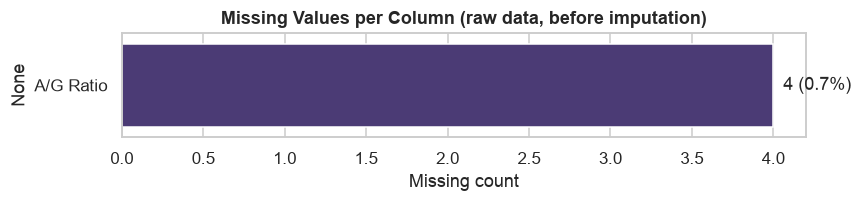

In [4]:
fig = eda.plot_missing_values(df, "liver")
plt.show()

**Interpretation:** Only `A/G Ratio` (albumin/globulin ratio) has missing
values (4 rows, <1%) - it is a computed/derived lab value, so it's plausible
it was simply not calculated for a handful of patients when the raw albumin
or globulin measurement was unavailable. This is negligible missingness and
median imputation is more than sufficient.


## 3. Disease Prevalence

2026-07-30 15:48:04,393 [INFO] Saved figure to /Users/albertmathew/Desktop/projects/MultiDiseaseAI/reports/figures/liver_prevalence.png


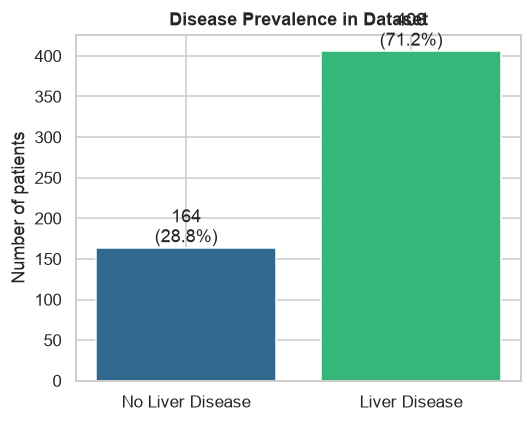

In [5]:
labels = {0: 'No Liver Disease', 1: 'Liver Disease'}
fig = eda.plot_target_prevalence(df, "target", labels, "liver")
plt.show()

**Interpretation:** 71.2% of patients in this dataset are liver-disease
positive - a substantial imbalance in the *opposite* direction from a typical
screening population (this is a dataset collected from patients already
presenting with symptoms, not a general population screen). This is the most
imbalanced of the four diseases in this project, so recall on the minority
(non-disease) class is watched closely in `evaluate.py` in addition to
overall accuracy.


## 4. Feature Distributions

2026-07-30 15:48:04,837 [INFO] Saved figure to /Users/albertmathew/Desktop/projects/MultiDiseaseAI/reports/figures/liver_distributions.png


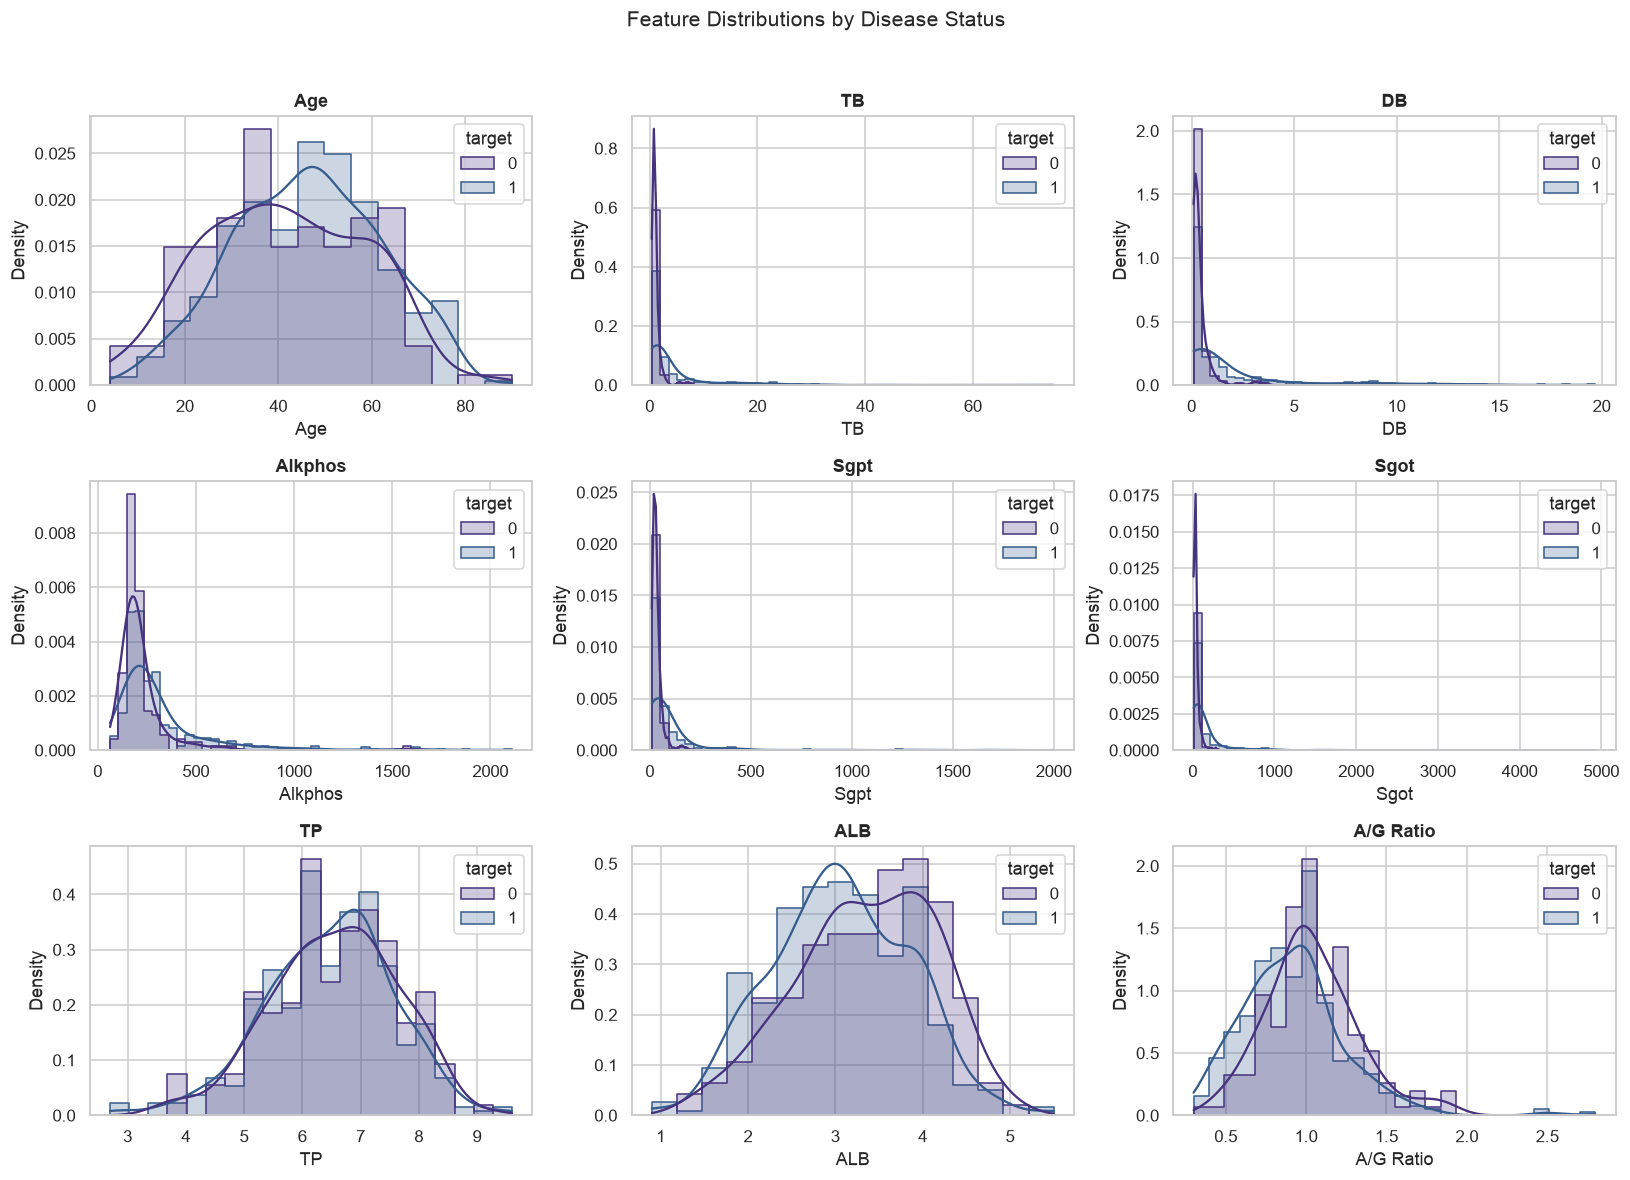

In [6]:
numeric_cols = ['Age', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'A/G Ratio']
fig = eda.plot_numeric_distributions(df, numeric_cols, "target", "liver")
plt.show()

**Interpretation:** `TB` (total bilirubin) and `DB` (direct bilirubin) are
both extremely right-skewed with a long tail of very high values in the
disease-positive group - consistent with jaundice/hyperbilirubinemia being a
hallmark of liver dysfunction. `Sgpt` (ALT) and `Sgot` (AST) show similar
right-skew with elevated values in disease-positive patients, matching their
clinical role as liver-enzyme injury markers.


## 5. Boxplots (Outlier Visualization)

2026-07-30 15:48:05,070 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:48:05,072 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:48:05,082 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:48:05,084 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:48:05,094 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


...

2026-07-30 15:48:05,153 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:48:05,155 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:48:05,165 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:48:05,167 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:48:05,353 [INFO] Saved figure to /Users/albertmathew/Desktop/projects/MultiDiseaseAI/reports/figures/liver_boxplots.png


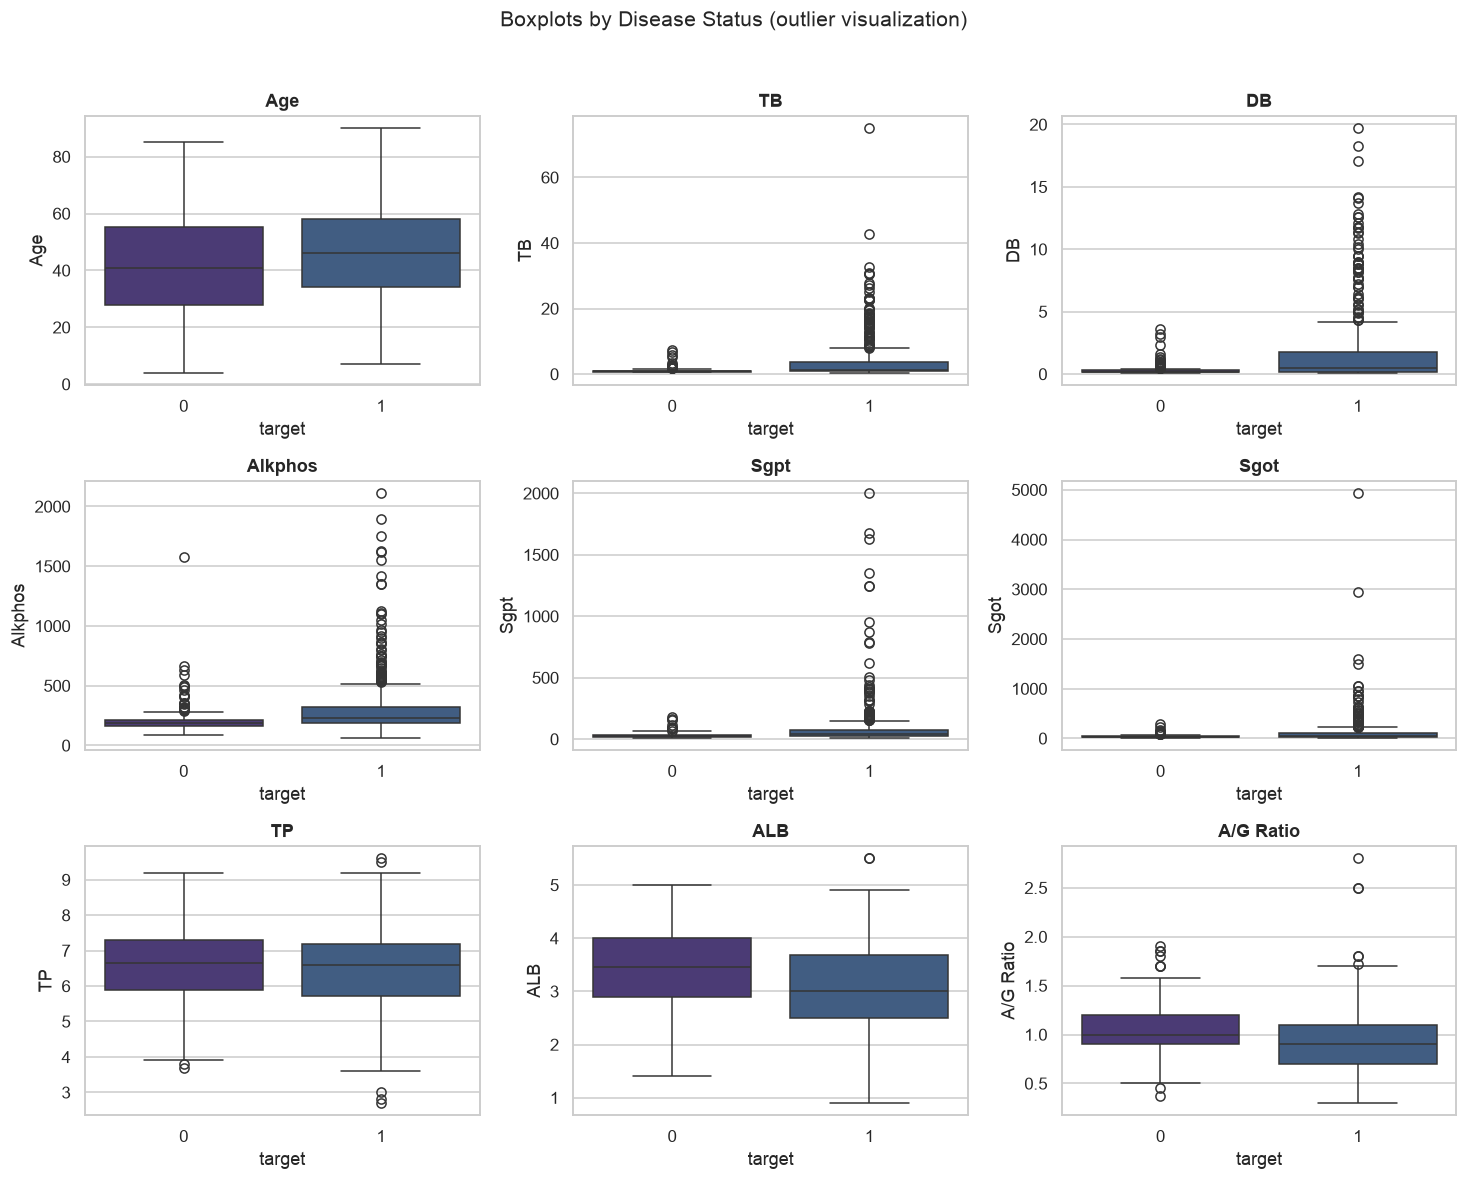

In [7]:
fig = eda.plot_boxplots(df, numeric_cols, "target", "liver")
plt.show()

**Interpretation:** `TB` and `DB` show the most extreme outliers by far
(some patients with bilirubin >20x the typical range) - clinically plausible
in severe hepatic disease (e.g. obstructive jaundice) rather than data-entry
errors, but exactly why winsorization (rather than deletion) is used in
preprocessing: extreme-but-real values are capped so they don't dominate
TabPFN's small in-context training set, without discarding genuinely
informative severe cases.


## 6. Correlation Matrix

2026-07-30 15:48:05,594 [INFO] Saved figure to /Users/albertmathew/Desktop/projects/MultiDiseaseAI/reports/figures/liver_correlation_heatmap.png


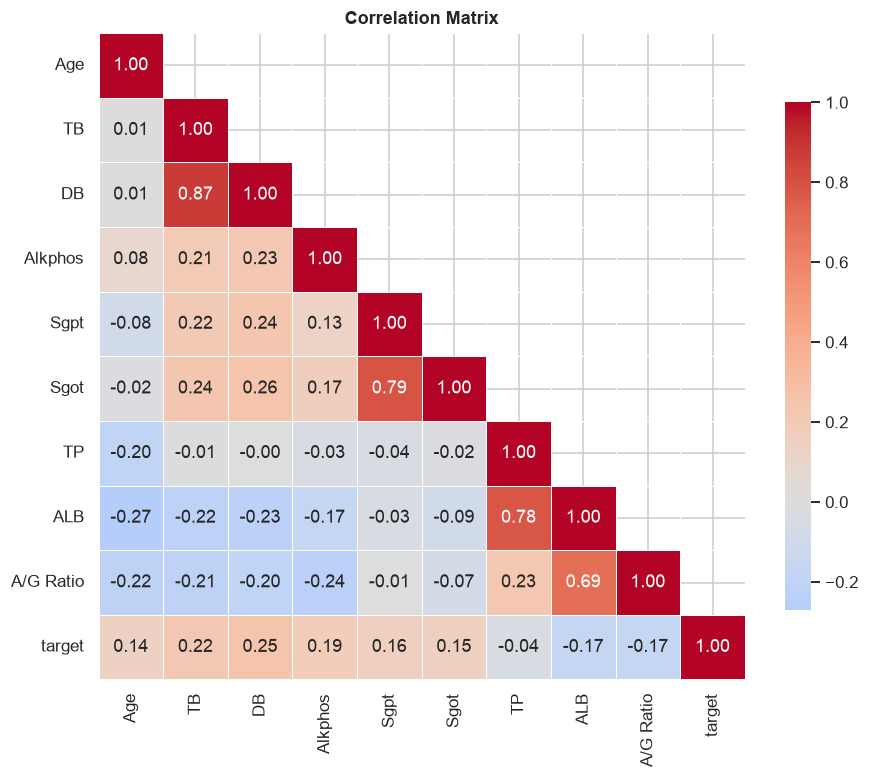

In [8]:
fig = eda.plot_correlation_heatmap(df, "liver")
plt.show()

In [9]:
eda.target_correlation_ranked(df, "target")

DB           0.250666
TB           0.224430
Alkphos      0.187560
A/G Ratio   -0.171402
ALB         -0.166835
Sgpt         0.161917
Sgot         0.151101
Age          0.138093
TP          -0.037794
Name: target, dtype: float64

**Interpretation:** Ranked by |correlation| with `target`: `DB` (0.25),
`TB` (0.22), `Alkphos` (0.19), `A/G Ratio` (-0.17), `ALB` (-0.17), `Sgpt`
(0.16). Correlations here are the weakest of the four diseases - liver
disease in this dataset is comparatively harder to separate linearly from
routine LFT values alone, which is exactly the kind of nonlinear,
interaction-heavy problem a tabular foundation model like TabPFN is designed
to handle better than a linear baseline. `TB` and `DB` are very highly
correlated with each other (direct bilirubin is a component of total
bilirubin by definition), motivating the `bilirubin_ratio` engineered feature
that captures their *relative* balance instead of just their magnitudes.


## 7. Pairplot of Top Correlated Features

2026-07-30 15:48:06,092 [INFO] Saved figure to /Users/albertmathew/Desktop/projects/MultiDiseaseAI/reports/figures/liver_pairplot.png


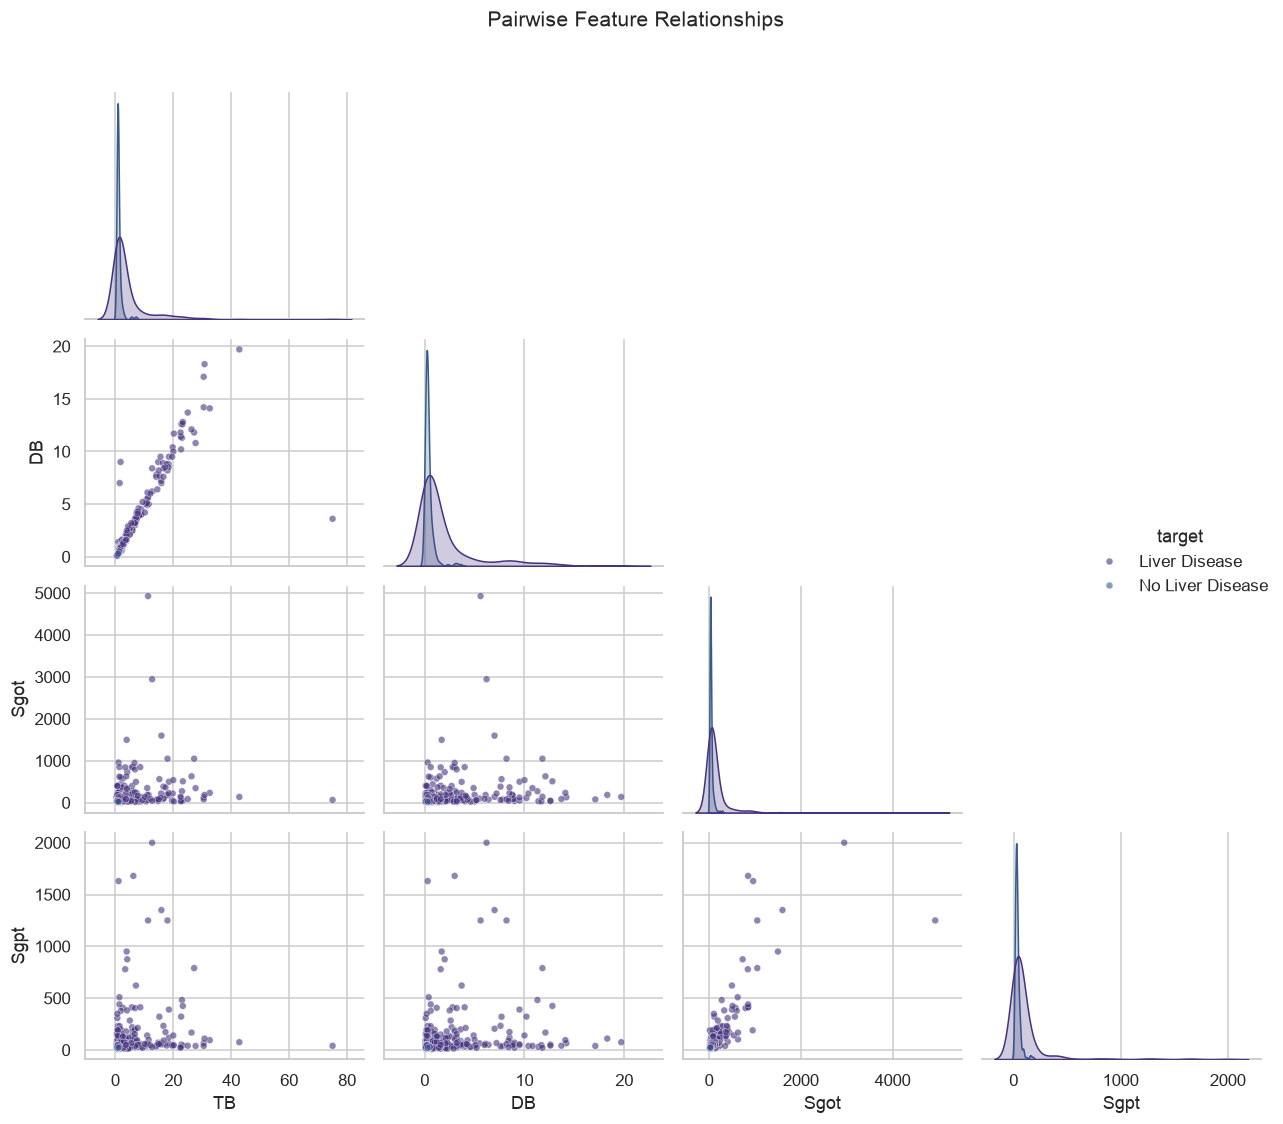

In [10]:
pair_cols = ['TB', 'DB', 'Sgot', 'Sgpt']
fig = eda.plot_pairplot(df, pair_cols, "target", "liver", labels)
plt.show()

**Interpretation:** `Sgot` vs `Sgpt` shows a roughly linear relationship with
a fan of increasing spread at higher values, and disease-positive patients
skew toward the upper end of both - motivating the `ast_alt_ratio` (De Ritis
ratio) engineered feature, which captures whether AST or ALT dominates
(clinically informative for distinguishing types of liver injury) rather
than just their absolute levels.


## 8. Summary of Findings

This EDA directly informs the choices made in `src/preprocessing.py` (imputation strategy, outlier clipping) and `src/feature_engineering.py` (which engineered features to add) for this disease. See `src/train.py` for how the cleaned, engineered features feed into the TabPFN model.